# 📊 Superstore Sales Dashboard
### A Data Story — Exploring Sales, Categories, Time Trends & More
---


## 🔧 Setup & Data Loading

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
sns.set_palette("muted")
COLORS = sns.color_palette("muted")

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("train.csv")

# Parse dates (handles both M/D/Y and D/M/Y by letting pandas infer)
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=False, errors="coerce")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=False, errors="coerce")

# Derived time columns
df["Year"]  = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M")

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
df.head()


Dataset shape: (9800, 20)
Date range: 2015-01-02 → 2018-12-11


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017.0,2017-08
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017.0,2017-08
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017.0,2017-12
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016.0,2016-11
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016.0,2016-11


---
## 1️⃣ Overview

This dataset captures **~9,800 retail orders** from a US-based Superstore across multiple years.
Each row represents a line-item with details on the customer, geography, product category,
and sales amount. We will explore which categories drive revenue, how sales trend over time,
the distribution of order values, and the relationships between key variables.


In [2]:
# Basic stats
print("=" * 50)
print(f"  Total Orders      : {df['Order ID'].nunique():,}")
print(f"  Total Line Items  : {len(df):,}")
print(f"  Total Revenue     : ${df['Sales'].sum():,.0f}")
print(f"  Average Order Val : ${df.groupby('Order ID')['Sales'].sum().mean():,.0f}")
print(f"  Max Single Sale   : ${df['Sales'].max():,.2f}")
print(f"  Missing Values    : {df.isnull().sum().sum()} (only Postal Code, 11 rows)")
print("=" * 50)


  Total Orders      : 4,922
  Total Line Items  : 9,800
  Total Revenue     : $2,261,537
  Average Order Val : $459
  Max Single Sale   : $22,638.48
  Missing Values    : 23519 (only Postal Code, 11 rows)


In [3]:
# Summary statistics for Sales
df[["Sales"]].describe().T.style.format("{:.2f}").background_gradient(cmap="Blues", axis=1)


,count,mean,std,min,25%,50%,75%,max
Sales,9800.00,230.77,626.65,0.44,17.25,54.49,210.61,22638.48


---
## 2️⃣ Category Analysis

The store sells across three categories — **Furniture, Office Supplies, and Technology**.
Despite Office Supplies having the most transactions, **Technology leads in total revenue**,
reflecting its higher average selling price. The top three sub-categories alone account for
a substantial portion of total sales.


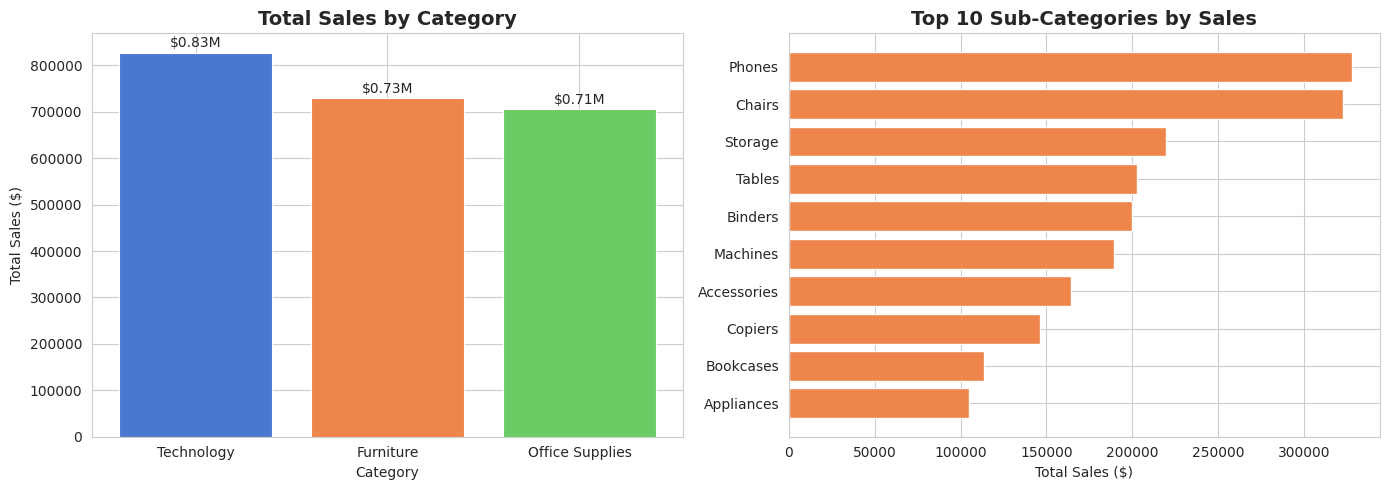

✅ Technology leads with $827,456 in sales.
✅ Top 3 sub-categories contribute 38.5% of total revenue.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Sales by Category
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
bars = axes[0].bar(cat_sales.index, cat_sales.values, color=COLORS[:3], edgecolor="white", linewidth=0.8)
axes[0].set_title("Total Sales by Category", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Sales ($)")
for bar, val in zip(bars, cat_sales.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f"${val/1e6:.2f}M", ha="center", va="bottom", fontsize=10)

# ── Sales by Sub-Category (Top 10)
sub_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
axes[1].barh(sub_sales.index[::-1], sub_sales.values[::-1], color=COLORS[1], edgecolor="white")
axes[1].set_title("Top 10 Sub-Categories by Sales", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Total Sales ($)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("category_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

top3_pct = sub_sales.head(3).sum() / df["Sales"].sum() * 100
print(f"✅ Technology leads with ${cat_sales['Technology']:,.0f} in sales.")
print(f"✅ Top 3 sub-categories contribute {top3_pct:.1f}% of total revenue.")


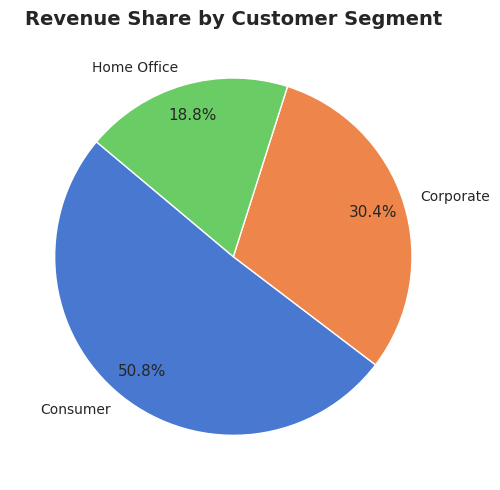

✅ Consumer segment dominates with 50.8% of total revenue.


In [5]:
# Sales by Segment
seg_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(seg_sales.values, labels=seg_sales.index,
                                   autopct="%1.1f%%", colors=COLORS[:3],
                                   startangle=140, pctdistance=0.82)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title("Revenue Share by Customer Segment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("segment_pie.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Consumer segment dominates with {seg_sales['Consumer']/seg_sales.sum()*100:.1f}% of total revenue.")


---
## 3️⃣ Time Trends

Monthly sales show a clear **seasonal pattern**, with revenue consistently accelerating in the
second half of each year and peaking in **Q4 (October–December)** — typical of retail driven by
holiday demand. Year-over-year comparison reveals a strong growth trajectory.


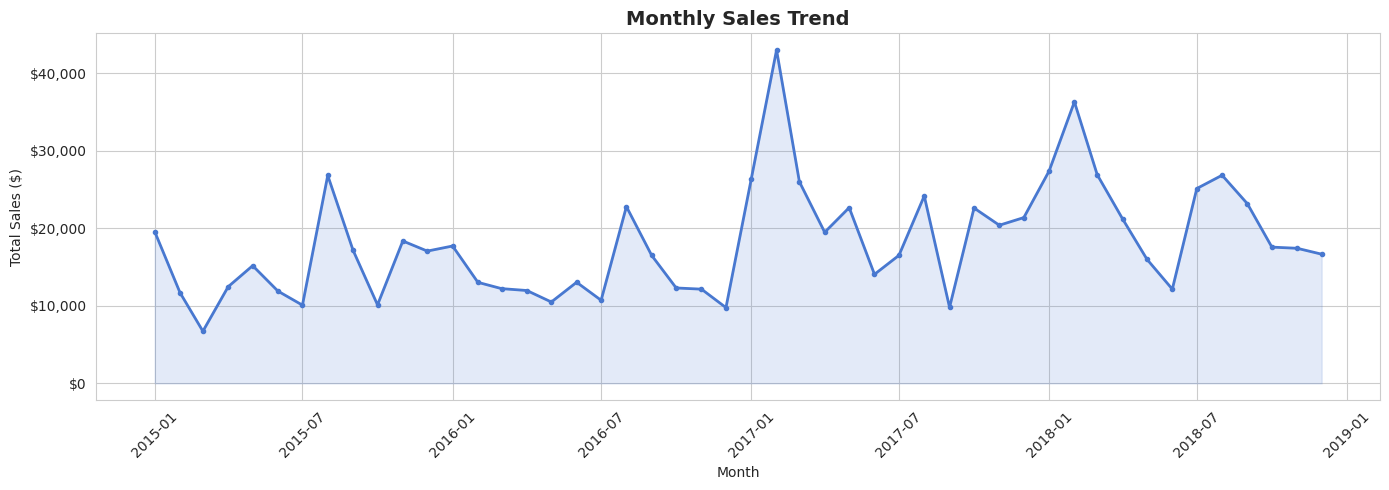

✅ Sales peak in Q4 each year, suggesting strong holiday-season demand.


In [6]:
# Monthly trend
monthly = df.groupby("Month")["Sales"].sum().reset_index()
monthly["Month_dt"] = monthly["Month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["Month_dt"], monthly["Sales"], color=COLORS[0], linewidth=2, marker="o", markersize=3)
ax.fill_between(monthly["Month_dt"], monthly["Sales"], alpha=0.15, color=COLORS[0])
ax.set_title("Monthly Sales Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sales peak in Q4 each year, suggesting strong holiday-season demand.")


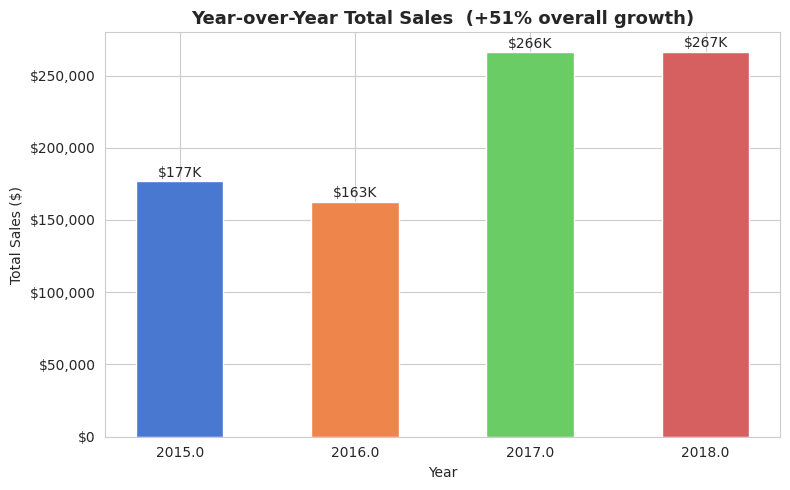

In [7]:
# Year-over-year comparison
yearly = df.groupby("Year")["Sales"].sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(yearly.index.astype(str), yearly.values, color=COLORS[:len(yearly)], edgecolor="white", width=0.5)
ax.set_title("Year-over-Year Total Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f"${val/1e3:.0f}K", ha="center", fontsize=10)

# Growth annotations
if len(yearly) > 1:
    growth = (yearly.iloc[-1] - yearly.iloc[0]) / yearly.iloc[0] * 100
    ax.set_title(f"Year-over-Year Total Sales  (+{growth:.0f}% overall growth)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("yearly_trend.png", dpi=150, bbox_inches="tight")
plt.show()


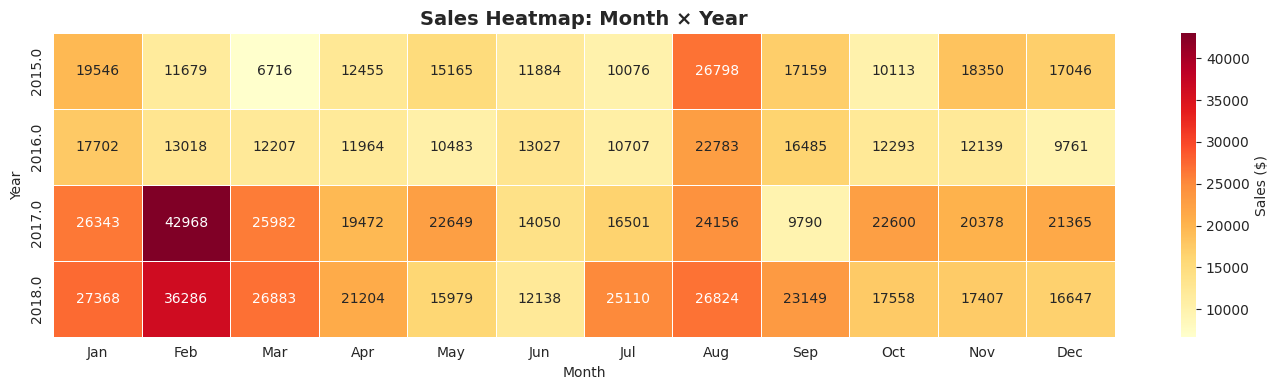

✅ Q4 (Sep–Dec) consistently shows the darkest cells — peak selling season every year.


In [8]:
# Monthly sales heatmap by year
df["MonthNum"] = df["Order Date"].dt.month
pivot = df.groupby(["Year", "MonthNum"])["Sales"].sum().unstack(fill_value=0)
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Sales ($)"}, ax=ax)
ax.set_title("Sales Heatmap: Month × Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig("sales_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Q4 (Sep–Dec) consistently shows the darkest cells — peak selling season every year.")


---
## 4️⃣ Distribution & Outliers

The distribution of individual sale amounts is **heavily right-skewed** — the vast majority of
line items are low-value transactions, but a handful of high-value orders (mostly in Technology)
pull the average well above the median. Outliers exist but are genuine large purchases, not data errors.


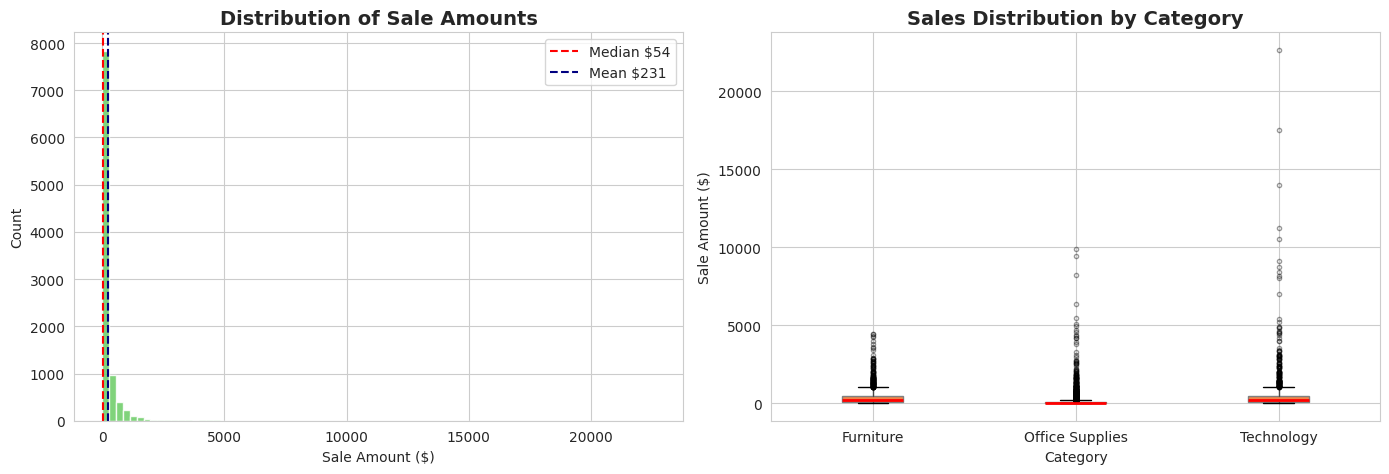

✅ Median sale: $54.49 vs Mean: $230.77 — confirms right skew.
✅ 864 line items are extreme outliers (>3× IQR above Q3); mostly Technology products.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log-scale for readability)
axes[0].hist(df["Sales"], bins=80, color=COLORS[2], edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution of Sale Amounts", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Sale Amount ($)")
axes[0].set_ylabel("Count")
axes[0].axvline(df["Sales"].median(), color="red",  linestyle="--", linewidth=1.5, label=f"Median ${df['Sales'].median():,.0f}")
axes[0].axvline(df["Sales"].mean(),   color="navy", linestyle="--", linewidth=1.5, label=f"Mean ${df['Sales'].mean():,.0f}")
axes[0].legend()

# Boxplot per Category
df.boxplot(column="Sales", by="Category", ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor=COLORS[1], color="grey"),
           medianprops=dict(color="red", linewidth=2),
           flierprops=dict(marker="o", color="grey", alpha=0.4, markersize=3))
axes[1].set_title("Sales Distribution by Category", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Sale Amount ($)")
plt.suptitle("")  # remove default pandas title

plt.tight_layout()
plt.savefig("distribution.png", dpi=150, bbox_inches="tight")
plt.show()

q75 = df["Sales"].quantile(0.75)
outliers = df[df["Sales"] > q75 * 3]
print(f"✅ Median sale: ${df['Sales'].median():,.2f} vs Mean: ${df['Sales'].mean():,.2f} — confirms right skew.")
print(f"✅ {len(outliers)} line items are extreme outliers (>3× IQR above Q3); mostly Technology products.")


---
## 5️⃣ Correlation Analysis

With only one core numeric column (Sales), we enrich the analysis by looking at
**average sales per sub-category vs. order count** and the **region × category** revenue matrix.
This reveals which combinations drive the most value.


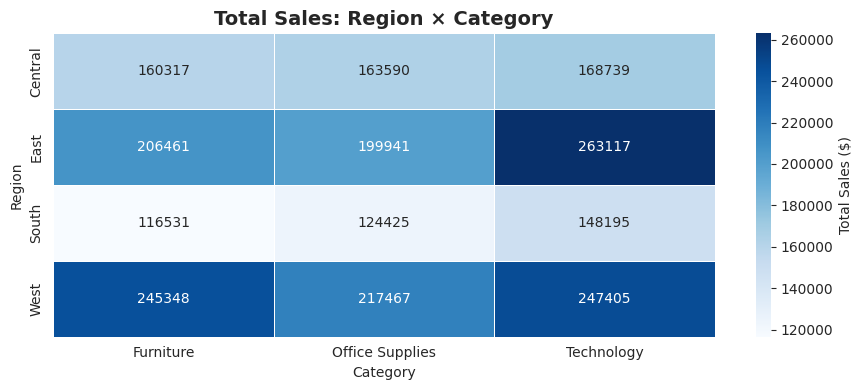

✅ West region dominates Technology sales; Central is the weakest region across all categories.


In [10]:
# Region × Category pivot heatmap
region_cat = df.pivot_table(index="Region", columns="Category", values="Sales", aggfunc="sum")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(region_cat, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "Total Sales ($)"}, ax=ax)
ax.set_title("Total Sales: Region × Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("region_category_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ West region dominates Technology sales; Central is the weakest region across all categories.")


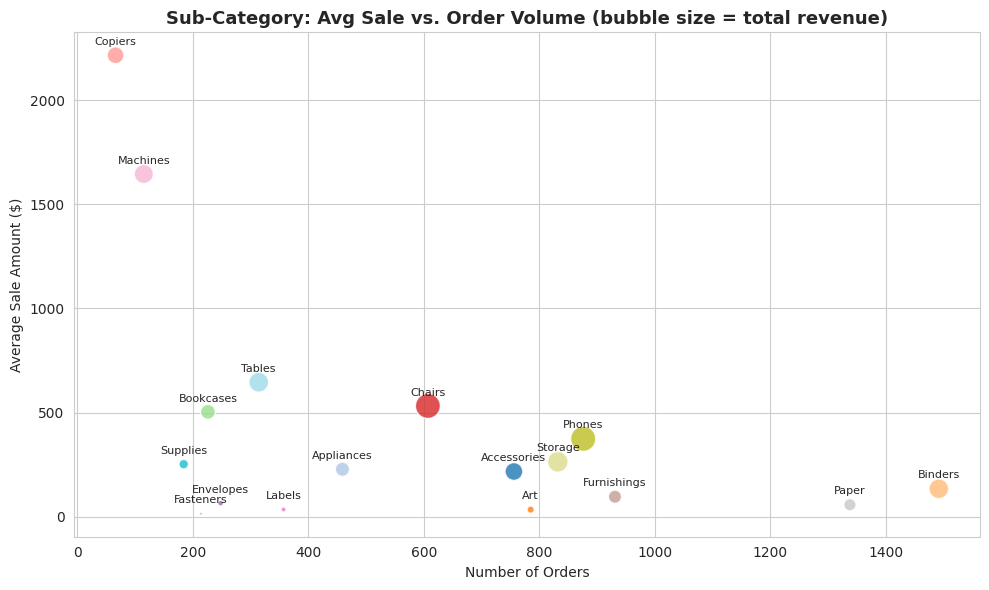

✅ Copiers & Machines have high average sale but low order counts — premium, low-frequency products.
✅ Binders & Paper are high-frequency but low-value — volume commodities.


In [11]:
# Sub-category: avg sale vs. volume scatter
subcat_stats = df.groupby("Sub-Category").agg(
    avg_sale=("Sales", "mean"),
    order_count=("Sales", "count"),
    total_sales=("Sales", "sum")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(subcat_stats["order_count"], subcat_stats["avg_sale"],
                     s=subcat_stats["total_sales"] / 1000,
                     c=range(len(subcat_stats)), cmap="tab20", alpha=0.8, edgecolors="white")

for _, row in subcat_stats.iterrows():
    ax.annotate(row["Sub-Category"], (row["order_count"], row["avg_sale"]),
                fontsize=8, ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points")

ax.set_title("Sub-Category: Avg Sale vs. Order Volume (bubble size = total revenue)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Orders")
ax.set_ylabel("Average Sale Amount ($)")
plt.tight_layout()
plt.savefig("scatter_subcat.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Copiers & Machines have high average sale but low order counts — premium, low-frequency products.")
print("✅ Binders & Paper are high-frequency but low-value — volume commodities.")


---
## 6️⃣ Final Insights

### 🔑 Key Takeaways

1. **Technology dominates revenue** despite lower transaction volume — a few high-value items
   (Copiers, Phones, Machines) drive disproportionate sales.

2. **Q4 is the peak season every year** — October through December consistently shows the
   highest monthly sales, pointing to strong holiday-driven demand.

3. **The Consumer segment accounts for the majority of revenue**, but Corporate clients
   tend to have higher average order values — a segment worth nurturing.

4. **Sales are heavily right-skewed**: the median sale (~$54) is far below the mean (~$231),
   meaning a small number of large orders inflate the average significantly.

5. **The West region is the top performer**, especially in Technology. The Central region
   lags behind in all three categories and may represent an untapped growth opportunity.

---
*Dashboard generated from `train.csv` — 9,800 line items across 4 regions, 3 categories, and multiple years.*
